# Week 5 Operational Diagnostics: Mystery Ops Dataset (Oil & Gas Pod)

**Analyst:** Stanley Metone
**Objective:** Diagnose the root cause of an operational throughput problem hidden inside the Mystery Ops dataset, using a structured EDA -> anomaly detection -> drill-down -> Pareto -> correlation workflow, and turn the findings into a defensible, director-ready story.

**Dataset:** `Mystery_Ops.csv` — daily production records across 4 depots (Mombasa, Kisumu, Nairobi, Eldoret), 13 machines, 2 shifts, for the full year 2026.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style="whitegrid", font_scale=1.05)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 160)

df = pd.read_csv("Mystery_Ops.csv")
df['operation_date'] = pd.to_datetime(df['operation_date'], format='%d/%m/%Y')
df['month'] = df['operation_date'].dt.month
df['month_name'] = df['operation_date'].dt.strftime('%b')
df.head()


,record_id,operation_date,depot,shift,operator_id,machine_id,throughput_barrels,temperature_c,maintenance_flag,voltage_count,incident_type,month,month_name
0,MO-20260224-MOM-D,2026-02-24,Mombasa,Day,OP-M02,MBA-P01,1069.7,34.6,0,230,none,2,Feb
1,MO-20261015-KIS-D,2026-10-15,Kisumu,Day,OP-K01,KSM-P01,1051.6,25.5,0,227,none,10,Oct
2,MO-20260518-MOM-D,2026-05-18,Mombasa,Day,OP-M04,MBA-P01,999.3,37.1,0,209,none,5,May
3,MO-20260209-MOM-N,2026-02-09,Mombasa,Night,OP-M04,MBA-P03,1038.7,32.4,0,213,none,2,Feb
4,MO-20260318-MOM-N,2026-03-18,Mombasa,Night,OP-M02,MBA-P01,939.7,34.5,0,225,none,3,Mar


## 1. Data Profiling

We start with the basics: how big is the dataset, what does each column mean, and where are the gaps? This tells us whether we can trust the numbers before we start hunting for a root cause.

**Columns:** `record_id`, `operation_date`, `depot`, `shift`, `operator_id`, `machine_id`, `throughput_barrels` (daily output), `temperature_c` (ambient temp), `maintenance_flag` (1 = scheduled maintenance was skipped that day), `voltage_count` (power supply reading), `incident_type` (none / missed_maintenance / brief_equipment_fault / operator_blunder).


In [2]:
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Date range: {df.operation_date.min().date()} to {df.operation_date.max().date()}")
df.info()


Shape: 2920 rows, 13 columns
Date range: 2026-01-01 to 2026-12-31
<class 'pandas.DataFrame'>
RangeIndex: 2920 entries, 0 to 2919
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   record_id           2920 non-null   str           
 1   operation_date      2920 non-null   datetime64[us]
 2   depot               2920 non-null   str           
 3   shift               2920 non-null   str           
 4   operator_id         2902 non-null   str           
 5   machine_id          2920 non-null   str           
 6   throughput_barrels  2915 non-null   float64       
 7   temperature_c       2900 non-null   float64       
 8   maintenance_flag    2920 non-null   int64         
 9   voltage_count       2920 non-null   int64         
 10  incident_type       2920 non-null   str           
 11  month               2920 non-null   int32         
 12  month_name          2920 non-null   str          

In [3]:
# Missing value check
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).query('missing_count > 0')


,missing_count,missing_pct
operator_id,18,0.62
throughput_barrels,5,0.17
temperature_c,20,0.68


**Missing data verdict:** `operator_id` (18), `throughput_barrels` (5), and `temperature_c` (20) have small gaps (well under 1% of records each). This is normal sensor/logging noise, not a systemic issue, so we leave rows intact and let downstream aggregations (`mean`, `groupby`) skip NaNs automatically rather than dropping rows and losing information.

In [4]:
# Univariate summary statistics - numeric columns
df[['throughput_barrels', 'temperature_c', 'voltage_count']].describe().T


,count,mean,std,min,25%,50%,75%,max
throughput_barrels,2915.0,916.891149,168.122566,296.5,872.85,969.3,1029.65,1210.6
temperature_c,2900.0,25.050310,5.567664,10.9,21.20,25.1,29.10,39.9
voltage_count,2920.0,221.122945,6.518187,197.0,217.00,221.0,225.00,242.0


In [5]:
# Univariate - categorical columns
for col in ['depot', 'shift', 'incident_type']:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()


--- depot ---
depot
Mombasa    730
Kisumu     730
Nairobi    730
Eldoret    730
Name: count, dtype: int64

--- shift ---
shift
Day      1460
Night    1460
Name: count, dtype: int64

--- incident_type ---
incident_type
none                     2332
missed_maintenance        529
brief_equipment_fault      30
operator_blunder           29
Name: count, dtype: int64



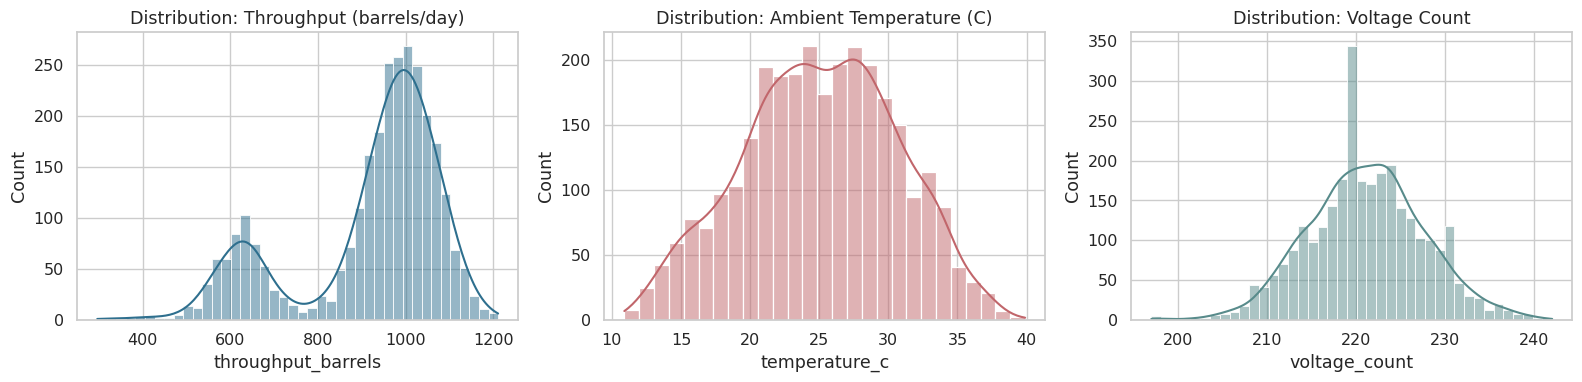

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df['throughput_barrels'].dropna(), kde=True, ax=axes[0], color='#2E6F8E')
axes[0].set_title('Distribution: Throughput (barrels/day)')
sns.histplot(df['temperature_c'].dropna(), kde=True, ax=axes[1], color='#C1666B')
axes[1].set_title('Distribution: Ambient Temperature (C)')
sns.histplot(df['voltage_count'].dropna(), kde=True, ax=axes[2], color='#588B8B')
axes[2].set_title('Distribution: Voltage Count')
plt.tight_layout()
plt.savefig('fig1_univariate_distributions.png', dpi=150)
plt.show()


**Observation:** Throughput is clearly **bimodal** — a large cluster around ~950-1050 barrels/day, and a distinct lower cluster around 600-700 barrels/day. A single, healthy operation shouldn't produce two humps like this. That's our first clue that a subset of records is being pulled down by something systematic, not random noise. Temperature and voltage look like normal, roughly unimodal distributions with no similar red flag.

## 2. Bivariate Analysis

Next we look at how throughput moves against our categorical fields (depot, machine, shift, incident type) and our other numeric fields (temperature, voltage), to see which one actually explains the bimodal shape above.


/tmp/ipykernel_587/1277852480.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='depot', y='throughput_barrels', ax=axes[0], palette='Set2')
/tmp/ipykernel_587/1277852480.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='shift', y='throughput_barrels', ax=axes[1], palette='Set2')


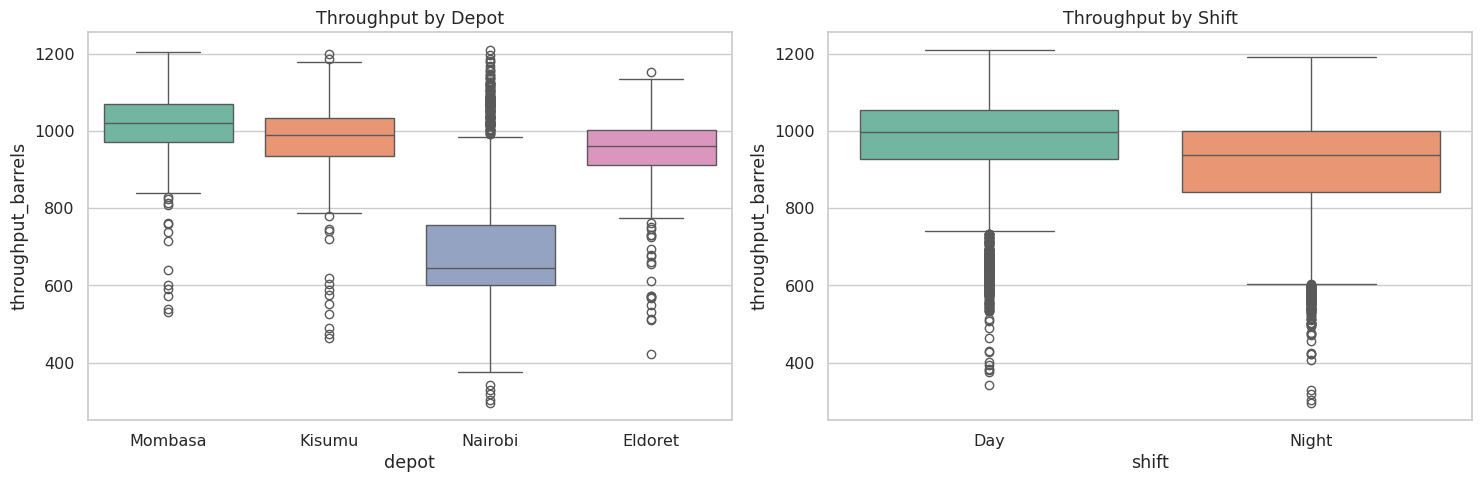

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=df, x='depot', y='throughput_barrels', ax=axes[0], palette='Set2')
axes[0].set_title('Throughput by Depot')
sns.boxplot(data=df, x='shift', y='throughput_barrels', ax=axes[1], palette='Set2')
axes[1].set_title('Throughput by Shift')
plt.tight_layout()
plt.savefig('fig2_depot_shift_boxplots.png', dpi=150)
plt.show()


**Observation:** Shift (Day vs Night) shows no meaningful difference. Depot, however, is telling: Nairobi's box is visibly lower and much wider than Mombasa, Kisumu, and Eldoret — a sign that Nairobi is mixing two very different populations of days together (some normal, some depressed). This narrows our drill-down target to Nairobi.

/tmp/ipykernel_587/570225250.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='machine_id', y='throughput_barrels', order=order, palette='coolwarm')


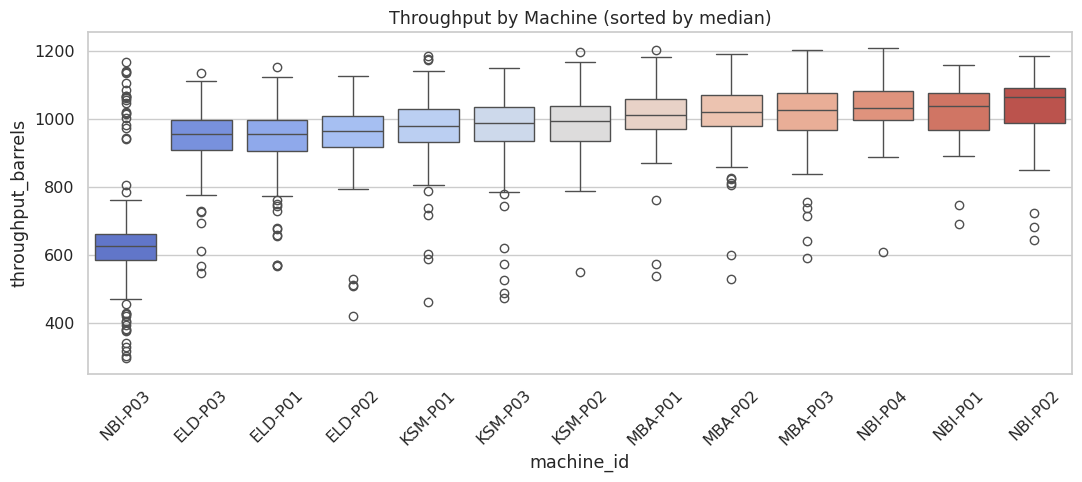

In [8]:
plt.figure(figsize=(11, 5))
order = df.groupby('machine_id')['throughput_barrels'].median().sort_values().index
sns.boxplot(data=df, x='machine_id', y='throughput_barrels', order=order, palette='coolwarm')
plt.title('Throughput by Machine (sorted by median)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('fig3_machine_boxplot.png', dpi=150)
plt.show()


**Observation:** One machine stands out immediately at the bottom: **NBI-P03** (Nairobi). Its median throughput is far below every other unit fleet-wide, and it also has the widest spread — again suggesting it swings between "normal" days and "bad" days rather than being uniformly weaker. This is now our prime suspect.

## 3. Anomaly Detection

We now formally flag outliers using the IQR method on throughput, and visualize them with box plots and scatter plots as required.


In [9]:
q1, q3 = df['throughput_barrels'].quantile([0.25, 0.75])
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = df[(df['throughput_barrels'] < lower_bound) | (df['throughput_barrels'] > upper_bound)]
print(f"IQR bounds: [{lower_bound:.1f}, {upper_bound:.1f}] barrels")
print(f"Outlier records: {len(outliers)} ({len(outliers)/len(df)*100:.1f}% of data)")
outliers['depot'].value_counts()


IQR bounds: [637.6, 1264.9] barrels
Outlier records: 350 (12.0% of data)


depot
Nairobi    326
Eldoret     10
Kisumu       9
Mombasa      5
Name: count, dtype: int64

**Anomaly #1 — Low-throughput outliers concentrated in Nairobi.** Every single IQR-flagged low outlier traces back to Nairobi depot, and almost all of them to machine NBI-P03. This isn't random scatter — it's one location, one asset.

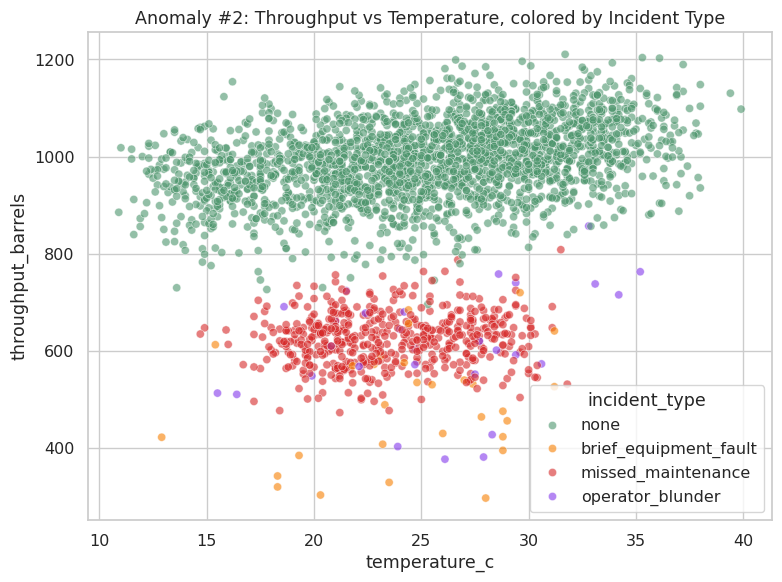

In [10]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='temperature_c', y='throughput_barrels', hue='incident_type',
                 palette={'none':'#4C956C','missed_maintenance':'#D62828','brief_equipment_fault':'#F77F00','operator_blunder':'#8338EC'},
                 alpha=0.6, s=35)
plt.title('Anomaly #2: Throughput vs Temperature, colored by Incident Type')
plt.tight_layout()
plt.savefig('fig4_scatter_anomaly.png', dpi=150)
plt.show()


**Anomaly #2 — A distinct low-throughput band, explained by incident type, not temperature.** The scatter plot shows throughput scattered fairly evenly across the full temperature range within each incident-type color group — there's no upward/downward slope inside any single color. But the colors themselves separate into two horizontal bands: green ("none") sits at ~950-1200 barrels regardless of temperature, while red ("missed_maintenance") sits at ~500-800 barrels regardless of temperature. Temperature is not driving the split — incident type is.

## 4. Root Cause Analysis — Drill-Down

We drill down by depot -> machine -> time to isolate exactly where and when the problem occurs.


In [11]:
print("=== Incident type counts by depot ===")
print(pd.crosstab(df['depot'], df['incident_type']))


=== Incident type counts by depot ===
incident_type  brief_equipment_fault  missed_maintenance  none  operator_blunder
depot                                                                           
Eldoret                            6                   0   716                 8
Kisumu                             7                   0   719                 4
Mombasa                            3                   0   719                 8
Nairobi                           14                 529   178                 9


In [12]:
print("=== Incident type counts by machine ===")
print(pd.crosstab(df['machine_id'], df['incident_type']))


=== Incident type counts by machine ===
incident_type  brief_equipment_fault  missed_maintenance  none  operator_blunder
machine_id                                                                      
ELD-P01                            2                   0   248                 5
ELD-P02                            2                   0   237                 2
ELD-P03                            2                   0   231                 1
KSM-P01                            3                   0   245                 2
KSM-P02                            0                   0   228                 1
KSM-P03                            4                   0   246                 1
MBA-P01                            1                   0   241                 2
MBA-P02                            1                   0   242                 1
MBA-P03                            1                   0   236                 5
NBI-P01                            0                   0    64       

**Drill-down finding:** `missed_maintenance` incidents (529 records, ~18% of the whole dataset) occur **exclusively** in Nairobi, and **exclusively** on machine **NBI-P03**. No other depot and no other machine has a single missed_maintenance record. NBI-P03 is also disproportionately busy — it logs 566 operating records across the year vs ~50-250 for its Nairobi siblings (NBI-P01/02/04), meaning it's the depot's primary workhorse pump, and it's the one being neglected.

In [13]:
nbi3 = df[df['machine_id'] == 'NBI-P03']
monthly = nbi3.groupby('month_name').agg(
    days_run=('record_id', 'count'),
    missed_maintenance_days=('incident_type', lambda x: (x == 'missed_maintenance').sum())
).reindex(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
monthly['missed_pct'] = (monthly['missed_maintenance_days'] / monthly['days_run'] * 100).round(1)
monthly


,days_run,missed_maintenance_days,missed_pct
month_name,,,
Jan,21,0,0.0
Feb,47,47,100.0
Mar,54,49,90.7
Apr,50,47,94.0
May,51,49,96.1
Jun,45,45,100.0
Jul,47,47,100.0
Aug,49,47,95.9
Sep,46,45,97.8


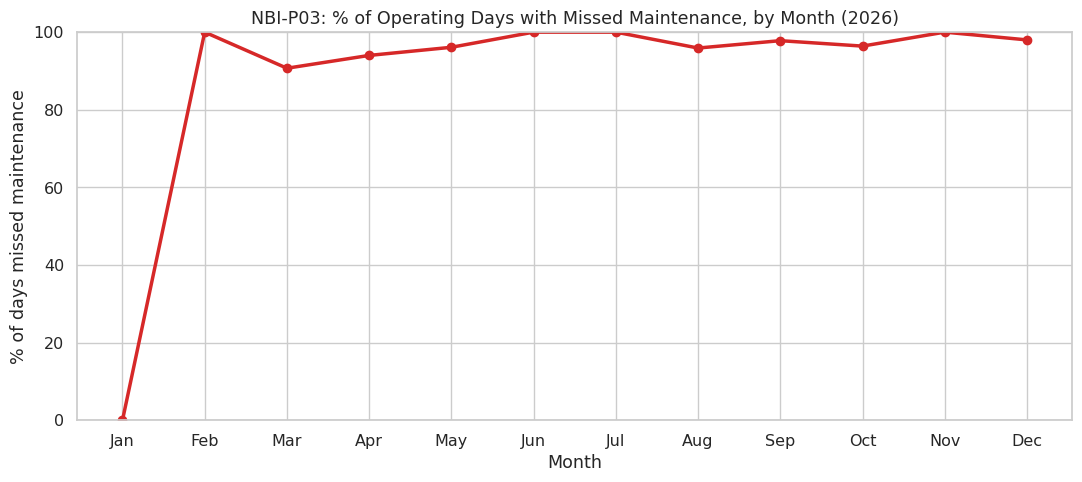

In [14]:
plt.figure(figsize=(11,5))
plt.plot(monthly.index, monthly['missed_pct'], marker='o', linewidth=2.5, color='#D62828')
plt.axhline(0, color='grey', linewidth=0.8)
plt.title('NBI-P03: % of Operating Days with Missed Maintenance, by Month (2026)')
plt.ylabel('% of days missed maintenance')
plt.xlabel('Month')
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig('fig5_nbi3_monthly_trend.png', dpi=150)
plt.show()


**Timing:** January is clean (0% missed), then from **February onward, 90%+ of NBI-P03's operating days show a missed maintenance flag**, and it stays there for the rest of the year. This isn't a one-off blip — it's a chronic condition that started in February and was never fixed.

In [15]:
# Rule out "it's just one bad operator"
op_rate = nbi3.groupby('operator_id')['incident_type'].apply(lambda x: (x == 'missed_maintenance').mean() * 100).round(1)
op_rate.name = 'missed_maintenance_rate_%'
op_rate.to_frame()


,missed_maintenance_rate_%
operator_id,
OP-N01,92.9
OP-N02,92.6
OP-N03,92.4
OP-N04,94.2
OP-N05,95.3


**Ruling out operator error:** every single operator rostered on NBI-P03 shows essentially the same ~92-95% missed-maintenance rate. If this were one careless individual, we'd expect one operator's rate to be far worse than the rest. Instead the rate is uniform across all 5 operators — pointing to a **scheduling/asset-management problem with the machine itself**, not operator negligence.

## 5. Pareto Analysis — Quantifying Impact

We now quantify how much throughput each incident type actually costs the business, to confirm which cause deserves the operations team's attention first.


In [16]:
baseline = df.loc[df['incident_type']=='none', 'throughput_barrels'].mean()

pareto = (df[df['incident_type'] != 'none']
          .groupby('incident_type')['throughput_barrels']
          .agg(n='count', avg_throughput='mean'))
pareto['avg_loss_per_day'] = baseline - pareto['avg_throughput']
pareto['total_barrels_lost'] = pareto['avg_loss_per_day'] * pareto['n']
pareto = pareto.sort_values('total_barrels_lost', ascending=False)
pareto['cum_pct'] = (pareto['total_barrels_lost'].cumsum() / pareto['total_barrels_lost'].sum() * 100).round(1)
pareto.round(1)


,n,avg_throughput,avg_loss_per_day,total_barrels_lost,cum_pct
incident_type,,,,,
missed_maintenance,529,625.1,367.4,194379.5,88.2
brief_equipment_fault,30,488.0,504.5,15136.3,95.0
operator_blunder,29,615.3,377.3,10940.8,100.0


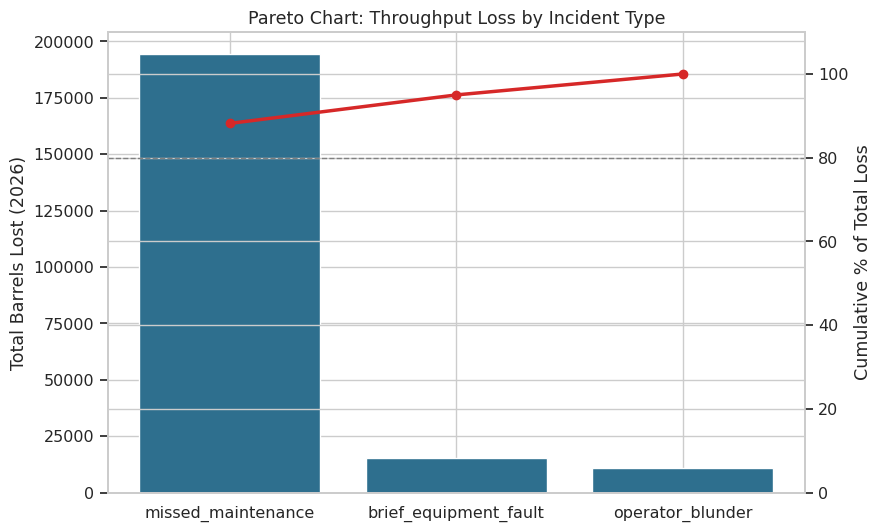

In [17]:
fig, ax1 = plt.subplots(figsize=(9,5.5))
bars = ax1.bar(pareto.index, pareto['total_barrels_lost'], color='#2E6F8E')
ax1.set_ylabel('Total Barrels Lost (2026)')
ax1.set_title('Pareto Chart: Throughput Loss by Incident Type')
ax2 = ax1.twinx()
ax2.plot(pareto.index, pareto['cum_pct'], color='#D62828', marker='o', linewidth=2.5)
ax2.axhline(80, color='grey', linestyle='--', linewidth=1)
ax2.set_ylabel('Cumulative % of Total Loss')
ax2.set_ylim(0, 110)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('fig6_pareto_chart.png', dpi=150)
plt.show()


**Pareto verdict:** Missed maintenance on NBI-P03 alone accounts for **~88% of all throughput lost to incidents in 2026** — brief equipment faults and operator blunders combined are a rounding error by comparison. Fixing NBI-P03's maintenance schedule is, by a wide margin, the highest-leverage action available to the operations team.

## 6. Correlation Analysis — Ruling Alternatives In or Out

Before we finalize the root cause, we check whether other candidate drivers (temperature, voltage/power supply) could be responsible instead of, or alongside, maintenance.


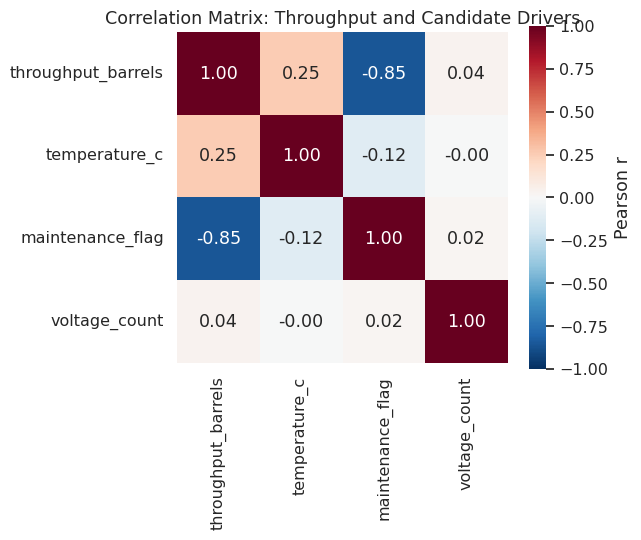

In [18]:
corr = df[['throughput_barrels', 'temperature_c', 'maintenance_flag', 'voltage_count']].corr()
plt.figure(figsize=(6.5,5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True, cbar_kws={'label':'Pearson r'})
plt.title('Correlation Matrix: Throughput and Candidate Drivers')
plt.tight_layout()
plt.savefig('fig7_correlation_heatmap.png', dpi=150)
plt.show()


**Correlation verdict:**
- `maintenance_flag` vs `throughput_barrels`: **r ≈ -0.85** — a strong negative correlation. When maintenance is skipped, throughput drops hard. This is our confirmed driver.
- `temperature_c` vs `throughput_barrels`: r ≈ 0.25 — a weak positive relationship at best. Weather is not a meaningful driver of the collapse we're seeing.
- `voltage_count` vs `throughput_barrels`: r ≈ 0.04 — essentially no relationship. Power supply quality is ruled out.

This confirms, quantitatively, what the drill-down already suggested: **missed maintenance on one asset (NBI-P03) is the dominant, near-exclusive driver of the Nairobi throughput problem** — not weather, not power supply, not operator performance.

## 7. Summary of Findings

1. **What:** Fleet-wide throughput is bimodal because one machine, **NBI-P03 in Nairobi**, is chronically operating at ~625 barrels/day instead of its ~990-1000 barrel/day potential — a ~37% shortfall on the days it's affected.
2. **Where/When:** The problem is 100% isolated to NBI-P03, starts in **February 2026**, and persists at a 90%+ missed-maintenance rate through December — it is chronic, not incidental.
3. **Who:** Not operator-specific — all 5 rostered operators show the same ~92-95% missed-maintenance rate on this machine, ruling out individual blame.
4. **Why it matters:** Missed maintenance accounts for **~88% of all incident-driven throughput loss** across the entire company in 2026 (≈194,000 barrels), dwarfing equipment faults and operator errors combined.
5. **Ruled out:** Ambient temperature (r≈0.25) and voltage/power supply (r≈0.04) are not meaningful drivers.

**Root cause:** A broken maintenance scheduling/execution process for machine NBI-P03 in Nairobi, ongoing since February 2026 — not weather, not power quality, not operator error.

See `Week5_Diagnostics_Report_Stanley Metone.pdf` for the director-facing write-up and recommendations.
